# Explore Dataset: Data Analysis and Vocabulary Visualization

This notebook:
- loads all papers from `Dataset/*.csv`
- harmonizes schema across files
- analyzes class distribution and text statistics
- visualizes vocabulary patterns per category with word clouds

In [16]:
import subprocess
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')


def ensure_wordcloud_installed():
    """Install wordcloud in the active kernel if missing."""
    try:
        from wordcloud import WordCloud  # noqa: F401
    except Exception:
        print('wordcloud package not found. Installing now...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud'])
        print('wordcloud installed successfully.')


ensure_wordcloud_installed()
from wordcloud import STOPWORDS, WordCloud

## Load Combined Dataset

Load the pre-cleaned and harmonized dataset from `data/combined_papers_cleaned.csv`

In [17]:
all_df = pd.read_csv('data/combined_papers_cleaned.csv')

print('Dataset loaded from: data/combined_papers_cleaned.csv')
print('Columns:', list(all_df.columns))

before = len(all_df)
all_df = all_df.dropna(subset=['label', 'title', 'abstract']).copy()
all_df['label'] = all_df['label'].astype(str).str.strip().str.upper()
all_df['title'] = all_df['title'].astype(str)
all_df['abstract'] = all_df['abstract'].astype(str)
after = len(all_df)

all_df['combined_text'] = (all_df['title'] + ' ' + all_df['abstract']).str.replace(r'\s+', ' ', regex=True).str.strip()
all_df = all_df[all_df['combined_text'].str.len() > 0].copy()

print('Rows before cleaning:', before)
print('Rows after cleaning :', after)
print('Final shape         :', all_df.shape)
all_df.head()

Dataset loaded from: data/combined_papers_cleaned.csv
Columns: ['label', 'title', 'abstract']
Rows before cleaning: 2855
Rows after cleaning : 2855
Final shape         : (2855, 4)


,label,title,abstract,combined_text
0,APPLIED,Towards Generalizable Robotic Manipulation in ...,Vision-Language-Action (VLA) models excel in s...,Towards Generalizable Robotic Manipulation in ...
1,APPLIED,Mixture-of-Depths Attention,Scaling depth is a key driver for large langua...,Mixture-of-Depths Attention Scaling depth is a...
2,APPLIED,Look Before Acting: Enhancing Vision Foundatio...,Vision-Language-Action (VLA) models have recen...,Look Before Acting: Enhancing Vision Foundatio...
3,APPLIED,HorizonMath: Measuring AI Progress Toward Math...,"Can AI make progress on important, unsolved ma...",HorizonMath: Measuring AI Progress Toward Math...
4,APPLIED,GlyphPrinter: Region-Grouped Direct Preference...,Generating accurate glyphs for visual text ren...,GlyphPrinter: Region-Grouped Direct Preference...


## Evaluate All Papers: Distribution and Text Statistics

,label,count,percentage
0,APPLIED,998,34.96
1,THEORETICAL,998,34.96
2,SURVEY,859,30.09


,label,papers,avg_chars,median_chars,avg_words,median_words
0,APPLIED,998,1474.75,1476.5,191.35,190.0
1,SURVEY,859,1177.36,1174.0,169.22,169.0
2,THEORETICAL,998,1267.79,1253.0,180.74,179.0


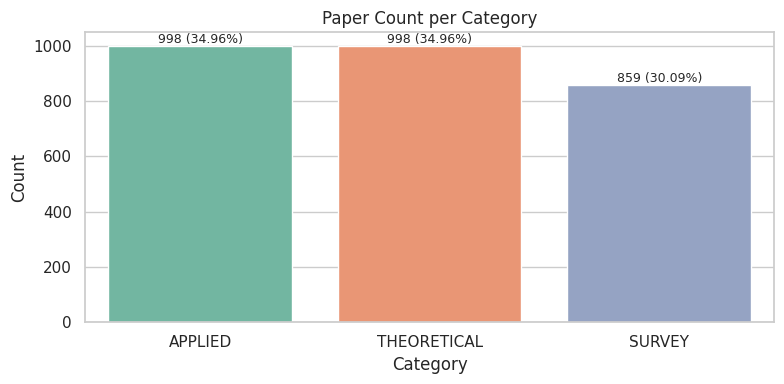

In [18]:
label_counts = all_df['label'].value_counts().sort_values(ascending=False)
label_pct = (label_counts / label_counts.sum() * 100).round(2)
dist_df = pd.DataFrame({
    'label': label_counts.index,
    'count': label_counts.values,
    'percentage': label_pct.values
})

display(dist_df)

all_df['text_char_len'] = all_df['combined_text'].str.len()
all_df['text_word_len'] = all_df['combined_text'].str.split().str.len()

len_stats = all_df.groupby('label', as_index=False).agg(
    papers=('label', 'size'),
    avg_chars=('text_char_len', 'mean'),
    median_chars=('text_char_len', 'median'),
    avg_words=('text_word_len', 'mean'),
    median_words=('text_word_len', 'median')
)

display(len_stats.round(2))

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=dist_df, x='label', y='count', hue='label', legend=False, palette='Set2')
for i, row in dist_df.reset_index(drop=True).iterrows():
    ax.text(i, row['count'], f"{int(row['count'])} ({row['percentage']}%)", ha='center', va='bottom', fontsize=9)
plt.title('Paper Count per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Text Preprocessing and Vocabulary Analysis

In [19]:
import re

def basic_tokenize(text):
    """Simple word tokenization: lowercase, split on whitespace and punctuation."""
    text = str(text).lower()
    tokens = re.findall(r'\b[a-z]+\b', text)
    return tokens

def get_top_words(texts, n=20):
    """Extract top n most frequent words from texts."""
    counter = Counter()
    for text in texts:
        counter.update(basic_tokenize(text))
    return counter.most_common(n)

# Analyze top words per category (raw, before stop word filtering)
print('Top 15 Raw Words per Category (before filtering)\n')
for label in sorted(all_df['label'].unique()):
    label_texts = all_df.loc[all_df['label'] == label, 'combined_text']
    top_words = get_top_words(label_texts, n=15)
    
    print(f'\n{label}:')
    print('-' * 50)
    for word, count in top_words:
        print(f'  {word:20s} : {count:5d}')

# Vocabulary richness per category
print('\n\n' + '=' * 60)
print('Vocabulary Richness Analysis')
print('=' * 60)

vocab_stats = []
for label in sorted(all_df['label'].unique()):
    label_texts = all_df.loc[all_df['label'] == label, 'combined_text']
    all_tokens = []
    for text in label_texts:
        all_tokens.extend(basic_tokenize(text))
    
    unique_tokens = len(set(all_tokens))
    total_tokens = len(all_tokens)
    vocabulary_ratio = unique_tokens / total_tokens if total_tokens > 0 else 0
    
    vocab_stats.append({
        'label': label,
        'unique_words': unique_tokens,
        'total_words': total_tokens,
        'vocabulary_ratio': vocabulary_ratio
    })

vocab_df = pd.DataFrame(vocab_stats)
display(vocab_df.round(4))

Top 15 Raw Words per Category (before filtering)


APPLIED:
--------------------------------------------------
  and                  :  6404
  the                  :  5743
  a                    :  4464
  to                   :  4381
  of                   :  3376
  in                   :  2749
  for                  :  2485
  we                   :  2227
  that                 :  2202
  on                   :  1828
  with                 :  1625
  this                 :  1292
  is                   :  1151
  by                   :  1070
  models               :  1050

SURVEY:
--------------------------------------------------
  the                  :  6839
  and                  :  5567
  of                   :  5537
  in                   :  3795
  to                   :  3430
  a                    :  3408
  we                   :  2214
  learning             :  2074
  for                  :  1811
  this                 :  1686
  on                   :  1545
  survey               

,label,unique_words,total_words,vocabulary_ratio
0,APPLIED,12111,200953,0.0603
1,SURVEY,7243,148822,0.0487
2,THEORETICAL,10311,188037,0.0548


## Word Cloud for Each Category

These clouds visualize frequent words per class using the full harmonized dataset text.

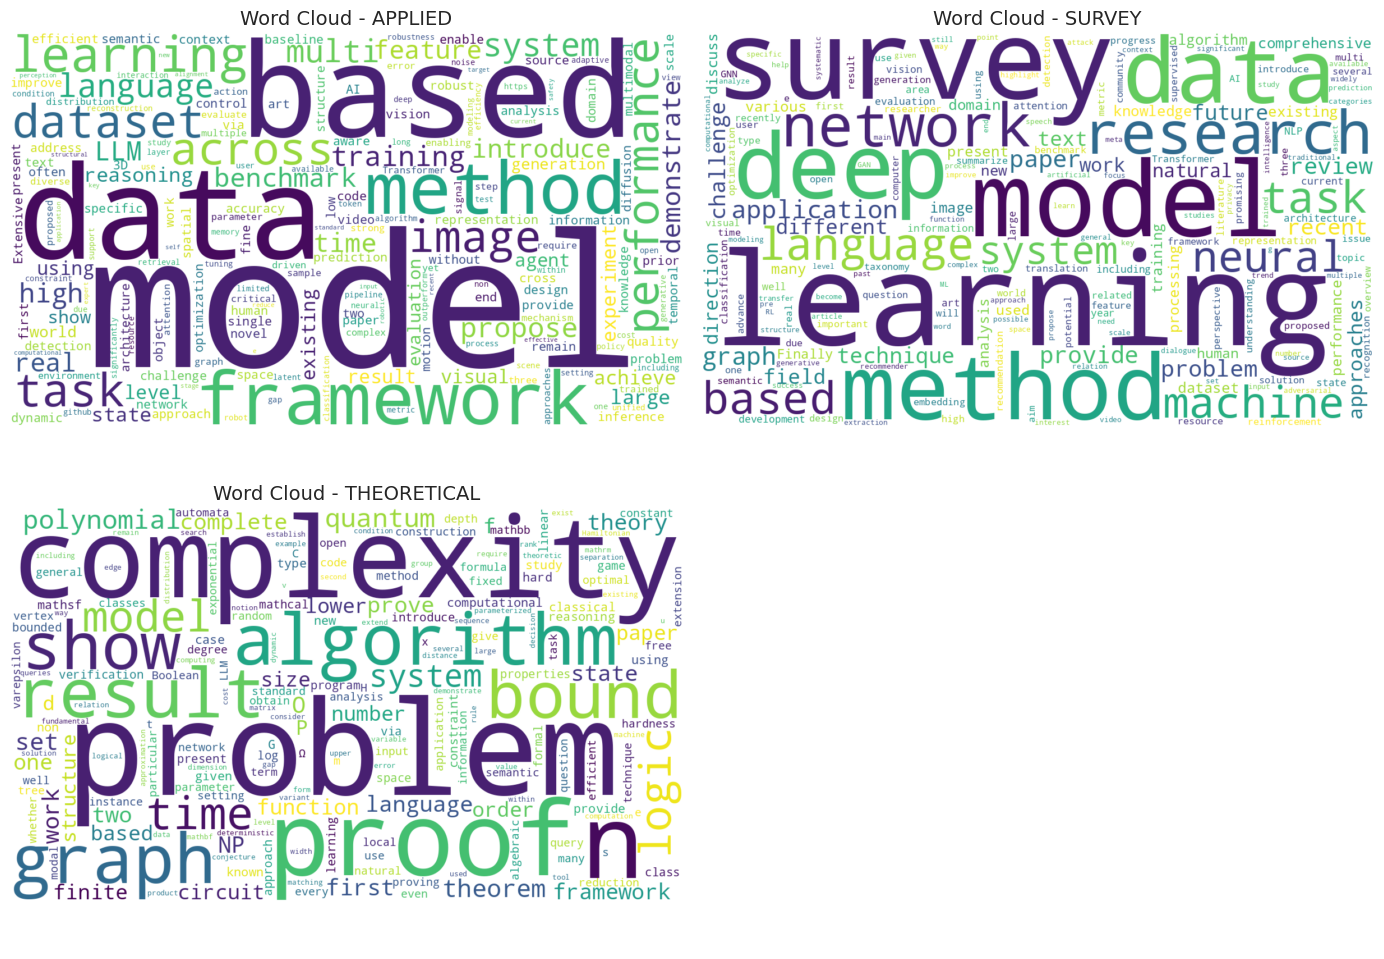

In [20]:
labels_sorted = sorted(all_df['label'].unique())
n_classes = len(labels_sorted)

ncols = 2
nrows = int(np.ceil(n_classes / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, label in enumerate(labels_sorted):
    text_blob = ' '.join(all_df.loc[all_df['label'] == label, 'combined_text'].tolist())

    wc = WordCloud(
        width=1200,
        height=700,
        background_color='white',
        stopwords=STOPWORDS,
        collocations=False,
        random_state=SEED
    ).generate(text_blob)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Word Cloud - {label}', fontsize=14)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()